<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/sql%2BJs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3

# Database create / connect
conn = sqlite3.connect('my_database.db')

# Cursor (SQL commands run karne ke liye)
cursor = conn.cursor()

print("Database connected!")

Database connected!


In [ ]:
cursor.execute("INSERT INTO students (name, age, marks) VALUES ('Ali', 20, 85)")
cursor.execute("INSERT INTO students (name, age, marks) VALUES ('Ahmed', 22, 90)")
cursor.execute("INSERT INTO students (name, age, marks) VALUES ('Sara', 19, 88)")

conn.commit()

print("Data inserted!")

Data inserted!


In [ ]:
cursor.execute("SELECT * FROM students")

rows = cursor.fetchall()

for row in rows:
    print(row)

(1, 'Ali', 20, 95)
(3, 'Sara', 19, 88)
(4, 'Ali', 20, 85)
(5, 'Ahmed', 22, 90)
(6, 'Sara', 19, 88)
(7, 'Ali', 20, 85)
(8, 'Ahmed', 22, 90)
(9, 'Sara', 19, 88)


In [ ]:
cursor.execute("SELECT * FROM students WHERE marks == 85")

rows = cursor.fetchall()

for row in rows:
    print(row)

(4, 'Ali', 20, 85)
(7, 'Ali', 20, 85)


In [ ]:
cursor.execute("UPDATE students SET marks = 95 WHERE name = 'Ali'")
conn.commit()

In [ ]:
cursor.execute("DELETE FROM students WHERE name = 'Ahmed'")
conn.commit()

In [ ]:
cursor.execute("SELECT * FROM students ORDER BY marks DESC")

rows = cursor.fetchall()

for row in rows:
    print(row)

(1, 'Ali', 20, 95)
(4, 'Ali', 20, 95)
(7, 'Ali', 20, 95)
(3, 'Sara', 19, 88)
(6, 'Sara', 19, 88)
(9, 'Sara', 19, 88)


## Step 1: load dataset

In [ ]:
import pandas as pd

df = pd.read_csv("google_play_store_updated.csv")

df.head()

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category,Size_in_Mb
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19922944.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,Moderate,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14680064.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,High,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,9122611.2,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,Very High,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,26214400.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,Top Notch,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2936012.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,More than moderate,2.8


# Step 2: Create SQLite database

In [ ]:
import sqlite3

conn = sqlite3.connect("googleplaystore.db")

# Step 3: Dataset ko SQL convert into table

In [ ]:
df.to_sql("googleplaystore", conn, if_exists="replace", index=False)

10346

tep 4: Run SQL queries

In [ ]:
query = "SELECT * FROM googleplaystore"

result = pd.read_sql(query, conn)

print(result)

                                                     App             Category  \
0         Photo Editor & Candy Camera & Grid & ScrapBook       ART_AND_DESIGN   
1                                    Coloring book moana       ART_AND_DESIGN   
2      U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
3                                  Sketch - Draw & Paint       ART_AND_DESIGN   
4                  Pixel Draw - Number Art Coloring Book       ART_AND_DESIGN   
...                                                  ...                  ...   
10341                                   Sya9a Maroc - FR               FAMILY   
10342                   Fr. Mike Schmitz Audio Teachings               FAMILY   
10343                             Parkinson Exercices FR              MEDICAL   
10344                      The SCP Foundation DB fr nn5n  BOOKS_AND_REFERENCE   
10345      iHoroscope - 2018 Daily Horoscope & Astrology            LIFESTYLE   

       Rating   Reviews  Si

# Step 5: Real Analysis

In [ ]:
query = "SELECT * FROM googleplaystore ORDER BY Rating DESC"

result = pd.read_sql(query, conn)

print(result)

                                              App             Category  \
0                    Hojiboy Tojiboyev Life Hacks               COMICS   
1                   American Girls Mobile Numbers               DATING   
2                                    Awake Dating               DATING   
3                           Spine- The dating app               DATING   
4      Girls Live Talk - Free Text and Video Chat               DATING   
...                                           ...                  ...   
10341                                   Cardio-FR              MEDICAL   
10342                          Naruto & Boruto FR               SOCIAL   
10343                    payermonstationnement.fr  MAPS_AND_NAVIGATION   
10344                                    FR Forms             BUSINESS   
10345                      Parkinson Exercices FR              MEDICAL   

       Rating  Reviews  Size_in_bytes  Installs  Type  Price Content Rating  \
0         5.0     15.0     38797

# 🔸 Top 10 rated apps

In [ ]:
query = "SELECT App, Rating FROM googleplaystore ORDER BY Rating DESC LIMIT 10"
pd.read_sql(query, conn)

,App,Rating
0,Hojiboy Tojiboyev Life Hacks,5.0
1,American Girls Mobile Numbers,5.0
2,Awake Dating,5.0
3,Spine- The dating app,5.0
4,Girls Live Talk - Free Text and Video Chat,5.0
5,Online Girls Chat Group,5.0
6,Speeding Joyride & Car Meet App,5.0
7,SUMMER SONIC app,5.0
8,Prosperity,5.0
9,Mindvalley U Tallinn 2018,5.0


🔸 # Free apps

In [ ]:
query = "SELECT App, Price FROM googleplaystore WHERE Price = '0'"
pd.read_sql(query, conn)

,App,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,0.0
1,Coloring book moana,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0.0
3,Sketch - Draw & Paint,0.0
4,Pixel Draw - Number Art Coloring Book,0.0
...,...,...
9579,Sya9a Maroc - FR,0.0
9580,Fr. Mike Schmitz Audio Teachings,0.0
9581,Parkinson Exercices FR,0.0
9582,The SCP Foundation DB fr nn5n,0.0


# 🔸 Category wise count

In [ ]:
query = "SELECT Category, COUNT(*) as total FROM googleplaystore GROUP BY Category"
pd.read_sql(query, conn)

,Category,total
0,ART_AND_DESIGN,64
1,AUTO_AND_VEHICLES,85
2,BEAUTY,53
3,BOOKS_AND_REFERENCE,229
4,BUSINESS,427
5,COMICS,60
6,COMMUNICATION,366
7,DATING,196
8,EDUCATION,130
9,ENTERTAINMENT,111


# EDA with SQL

### Step 1: check the Table

In [ ]:
query = "SELECT * FROM googleplaystore LIMIT 5"
pd.read_sql(query, conn)

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category,Size_in_Mb
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19922944.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,Moderate,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14680064.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,High,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,9122611.2,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,Very High,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,26214400.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,Top Notch,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2936012.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,More than moderate,2.8


## Step 2: Total rows (data size)

In [ ]:
query = "SELECT COUNT(*) as total_apps FROM googleplaystore"
pd.read_sql(query, conn)

,total_apps
0,10346


### Step 3: Unique categories

In [ ]:
query = "SELECT DISTINCT Category FROM googleplaystore"
pd.read_sql(query, conn)

,Category
0,ART_AND_DESIGN
1,AUTO_AND_VEHICLES
2,BEAUTY
3,BOOKS_AND_REFERENCE
4,BUSINESS
5,COMICS
6,COMMUNICATION
7,DATING
8,EDUCATION
9,ENTERTAINMENT


### 4: Category wise analysis

In [ ]:
query = """
SELECT Category, COUNT(*) as total_apps
FROM googleplaystore
GROUP BY Category
ORDER BY total_apps DESC
"""
pd.read_sql(query, conn)

,Category,total_apps
0,FAMILY,1939
1,GAME,1121
2,TOOLS,841
3,BUSINESS,427
4,MEDICAL,408
5,PRODUCTIVITY,407
6,PERSONALIZATION,386
7,LIFESTYLE,373
8,COMMUNICATION,366
9,FINANCE,360


### Step 5: Free vs Paid apps

In [ ]:
query = """
SELECT Type, COUNT(*) as total
FROM googleplaystore
GROUP BY Type
"""
pd.read_sql(query, conn)

,Type,total
0,Free,9584
1,Paid,762


### Step 6: Average rating per category

In [ ]:
query = """
SELECT Category, AVG(Rating) as avg_rating
FROM googleplaystore
GROUP BY Category
ORDER BY avg_rating DESC
"""
pd.read_sql(query, conn)

,Category,avg_rating
0,EDUCATION,4.342308
1,ART_AND_DESIGN,4.171875
2,ENTERTAINMENT,4.136036
3,GAME,4.101784
4,COMICS,4.016667
5,PHOTOGRAPHY,3.949068
6,WEATHER,3.881707
7,SHOPPING,3.833929
8,VIDEO_PLAYERS,3.715429
9,FAMILY,3.711398


### Step 7: Top rated apps

In [ ]:
query = """
SELECT App, Rating
FROM googleplaystore
ORDER BY Rating DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,App,Rating
0,Hojiboy Tojiboyev Life Hacks,5.0
1,American Girls Mobile Numbers,5.0
2,Awake Dating,5.0
3,Spine- The dating app,5.0
4,Girls Live Talk - Free Text and Video Chat,5.0
5,Online Girls Chat Group,5.0
6,Speeding Joyride & Car Meet App,5.0
7,SUMMER SONIC app,5.0
8,Prosperity,5.0
9,Mindvalley U Tallinn 2018,5.0


### Step 8: Most reviewed apps

In [ ]:
query = """
SELECT App, Reviews
FROM googleplaystore
ORDER BY Reviews DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,App,Reviews
0,Facebook,78158306.0
1,Facebook,78128208.0
2,WhatsApp Messenger,69119316.0
3,WhatsApp Messenger,69109672.0
4,Instagram,66577446.0
5,Instagram,66577313.0
6,Instagram,66509917.0
7,Messenger – Text and Video Chat for Free,56646578.0
8,Messenger – Text and Video Chat for Free,56642847.0
9,Clash of Clans,44893888.0


### Step 9: Installs analysis

In [ ]:
query = """
SELECT App, Installs
FROM googleplaystore
ORDER BY Installs DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,App,Installs
0,Google Play Books,1.000000e+09
1,Messenger – Text and Video Chat for Free,1.000000e+09
2,WhatsApp Messenger,1.000000e+09
3,Google Chrome: Fast & Secure,1.000000e+09
4,Gmail,1.000000e+09
5,Hangouts,1.000000e+09
6,Messenger – Text and Video Chat for Free,1.000000e+09
7,Hangouts,1.000000e+09
8,Skype - free IM & video calls,1.000000e+09
9,Google Chrome: Fast & Secure,1.000000e+09


### Step 10: Paid apps price analysis

In [ ]:
query = """
SELECT MAX(Price) as max_price,
       MIN(Price) as min_price,
       AVG(Price) as avg_price
FROM googleplaystore
WHERE Type = 'Paid'
"""
pd.read_sql(query, conn)

,max_price,min_price,avg_price
0,400.0,0.99,14.005945


### Step 11: Missing values check (SQL trick)

In [ ]:
query = """
SELECT COUNT(*) as missing_rating
FROM googleplaystore
WHERE Rating IS NULL
"""
pd.read_sql(query, conn)

,missing_rating
0,0


### Columns names

In [ ]:
query = "PRAGMA table_info(googleplaystore)"
columns = pd.read_sql(query, conn)

print(columns['name'])

0                   App
1              Category
2                Rating
3               Reviews
4         Size_in_bytes
5              Installs
6                  Type
7                 Price
8        Content Rating
9                Genres
10         Last Updated
11          Current Ver
12          Android Ver
13    Installs_category
14           Size_in_Mb
Name: name, dtype: object


##1. Best Categories

In [ ]:
query = """
SELECT Category, COUNT(*) as total_apps
FROM googleplaystore
GROUP BY Category
ORDER BY total_apps DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,Category,total_apps
0,FAMILY,1939
1,GAME,1121
2,TOOLS,841
3,BUSINESS,427
4,MEDICAL,408


## 2. High Rating + High Installs apps

In [ ]:
query = """
SELECT App, Rating, Installs
FROM googleplaystore
WHERE Rating >= 4.5 AND Installs > 1000000
ORDER BY Rating DESC
"""
pd.read_sql(query, conn)

,App,Rating,Installs
0,Lose Belly Fat in 30 Days - Flat Stomach,4.9,5000000.0
1,Six Pack in 30 Days - Abs Workout,4.9,10000000.0
2,Six Pack in 30 Days - Abs Workout,4.9,10000000.0
3,JW Library,4.9,10000000.0
4,Fines of the State Traffic Safety Inspectorate...,4.8,5000000.0
...,...,...,...
838,Garena Free Fire,4.5,100000000.0
839,Angry Birds Space HD,4.5,5000000.0
840,Family Guy- Another Freakin' Mobile Game,4.5,5000000.0
841,Photo Editor Collage Maker Pro,4.5,100000000.0


### 3. Free vs Paid performance comparison

In [ ]:
query = """
SELECT Type, AVG(Rating) as avg_rating, COUNT(*) as total_apps
FROM googleplaystore
GROUP BY Type
"""
pd.read_sql(query, conn)

,Type,avg_rating,total_apps
0,Free,3.611258,9584
1,Paid,3.417192,762


## 4. Top reviews apps

In [ ]:
query = """
SELECT App, Reviews
FROM googleplaystore
ORDER BY Reviews DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,App,Reviews
0,Facebook,78158306.0
1,Facebook,78128208.0
2,WhatsApp Messenger,69119316.0
3,WhatsApp Messenger,69109672.0
4,Instagram,66577446.0


### 5. Category wise average installs

In [ ]:
query = """
SELECT Category, AVG(Installs) as avg_installs
FROM googleplaystore
GROUP BY Category
ORDER BY avg_installs DESC
"""
pd.read_sql(query, conn)

,Category,avg_installs
0,COMMUNICATION,6.598983e+07
1,SOCIAL,4.469239e+07
2,VIDEO_PLAYERS,3.555430e+07
3,PRODUCTIVITY,3.062185e+07
4,PHOTOGRAPHY,3.019021e+07
5,GAME,2.813918e+07
6,TRAVEL_AND_LOCAL,2.684341e+07
7,ENTERTAINMENT,2.212306e+07
8,NEWS_AND_MAGAZINES,2.042886e+07
9,TOOLS,1.361745e+07


### 6. Paid apps ka business analysis

In [ ]:
query = """
SELECT Category, AVG(Price) as avg_price
FROM googleplaystore
WHERE Type = 'Paid'
GROUP BY Category
ORDER BY avg_price DESC
"""
pd.read_sql(query, conn)

,Category,avg_price
0,FINANCE,170.637059
1,LIFESTYLE,124.256316
2,EVENTS,109.990000
3,BUSINESS,14.607500
4,FAMILY,13.009839
5,MEDICAL,12.151071
6,PRODUCTIVITY,8.961786
7,PHOTOGRAPHY,6.111500
8,MAPS_AND_NAVIGATION,5.390000
9,SOCIAL,5.323333


### 7. Low rating apps (problem identify)

In [ ]:
query = """
SELECT App, Rating
FROM googleplaystore
WHERE Rating < 3
ORDER BY Rating ASC
"""
pd.read_sql(query, conn)

,App,Rating
0,Mcqueen Coloring pages,0.0
1,Wrinkles and rejuvenation,0.0
2,Manicure - nail design,0.0
3,Skin Care and Natural Beauty,0.0
4,"Secrets of beauty, youth and health",0.0
...,...,...
1735,Safe Wi-Fi,2.9
1736,fi,2.9
1737,Employ Florida Mobile,2.9
1738,SB · FN 1870 Mobile Banking,2.9


### 8. Duplicate apps

In [ ]:
query = """
SELECT App, COUNT(*) as count
FROM googleplaystore
GROUP BY App
HAVING count > 1
"""
pd.read_sql(query, conn)

,App,count
0,365Scores - Live Scores,2
1,8 Ball Pool,7
2,95Live -SG#1 Live Streaming App,2
3,A&E - Watch Full Episodes of TV Shows,2
4,AC - Tips & News for Android™,2
...,...,...
518,slither.io,5
519,stranger chat - anonymous chat,2
520,textPlus: Free Text & Calls,2
521,"theScore: Live Sports Scores, News, Stats & Vi...",2


### Top 3 most “overpriced” paid apps 💰

In [ ]:
query = """
SELECT App, Price, Rating
FROM googleplaystore
WHERE Type='Paid'
ORDER BY Price DESC
LIMIT 3
"""
pd.read_sql(query, conn)

,App,Price,Rating
0,I'm Rich - Trump Edition,400.00,3.6
1,most expensive app (H),399.99,4.3
2,💎 I'm rich,399.99,3.8


### Most installed apps per category

In [ ]:
query = """
SELECT Category, App, Installs
FROM googleplaystore
WHERE Installs IS NOT NULL
ORDER BY Installs DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,Category,App,Installs
0,BOOKS_AND_REFERENCE,Google Play Books,1.000000e+09
1,COMMUNICATION,Messenger – Text and Video Chat for Free,1.000000e+09
2,COMMUNICATION,WhatsApp Messenger,1.000000e+09
3,COMMUNICATION,Google Chrome: Fast & Secure,1.000000e+09
4,COMMUNICATION,Gmail,1.000000e+09


### Rating  top categories

In [ ]:
query = """
SELECT Category, AVG(Rating) as avg_rating
FROM googleplaystore
GROUP BY Category
ORDER BY avg_rating DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,Category,avg_rating
0,EDUCATION,4.342308
1,ART_AND_DESIGN,4.171875
2,ENTERTAINMENT,4.136036
3,GAME,4.101784
4,COMICS,4.016667


### Rating top categories

In [ ]:
query = """
SELECT Category, AVG(Rating) as avg_rating
FROM googleplaystore
GROUP BY Category
ORDER BY avg_rating DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,Category,avg_rating
0,EDUCATION,4.342308
1,ART_AND_DESIGN,4.171875
2,ENTERTAINMENT,4.136036
3,GAME,4.101784
4,COMICS,4.016667


### Free vs Paid installs comparison

In [ ]:
query = """
SELECT Type, SUM(Installs) as total_installs
FROM googleplaystore
GROUP BY Type
"""
pd.read_sql(query, conn)

,Type,total_installs
0,Free,1.465612e+11
1,Paid,6.917487e+07


### Category wise “hidden gems”

In [ ]:
query = """
SELECT App, Category, Rating, Installs
FROM googleplaystore
WHERE Rating >= 4.5 AND Installs < 100000
ORDER BY Rating DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,App,Category,Rating,Installs
0,Hojiboy Tojiboyev Life Hacks,COMICS,5.0,1000.0
1,American Girls Mobile Numbers,DATING,5.0,1000.0
2,Awake Dating,DATING,5.0,100.0
3,Spine- The dating app,DATING,5.0,500.0
4,Girls Live Talk - Free Text and Video Chat,DATING,5.0,100.0
5,Online Girls Chat Group,DATING,5.0,100.0
6,Speeding Joyride & Car Meet App,DATING,5.0,100.0
7,SUMMER SONIC app,EVENTS,5.0,500.0
8,Prosperity,EVENTS,5.0,100.0
9,Mindvalley U Tallinn 2018,EVENTS,5.0,100.0


### Most “neglected” apps (low rating + high installs) ⚠️

In [ ]:
query = """
SELECT App, Category, Rating, Installs
FROM googleplaystore
WHERE Rating < 3 AND Installs > 100000
ORDER BY Installs DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,App,Category,Rating,Installs
0,AppFinder by AppTap,TOOLS,2.0,5000000.0
1,3D Holograms Joke,FAMILY,2.9,5000000.0
2,Android TV Remote Service,TOOLS,0.0,1000000.0
3,SD card backup,TOOLS,0.0,1000000.0
4,How Old am I?,FAMILY,2.8,1000000.0
5,Moto Z Market,TOOLS,2.2,1000000.0
6,Club Penguin Island,FAMILY,2.8,1000000.0
7,PS4 Second Screen,FAMILY,2.4,1000000.0
8,AirWatch Inbox,BUSINESS,2.7,1000000.0
9,BT Notifier,TOOLS,2.5,1000000.0


### Fun trick: “Pricey but low rating” combos

In [ ]:
query = """
SELECT App, Price, Rating
FROM googleplaystore
WHERE Type='Paid' AND Rating < 3
ORDER BY Price DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,App,Price,Rating
0,I'm Rich/Eu sou Rico/أنا غني/我很有錢,399.99,0.0
1,Eu Sou Rico,394.99,0.0
2,I am extremely Rich,379.99,2.9
3,EP Cook Book,200.00,0.0
4,cronometra-br,154.99,0.0


### Category ka “Super Star” App

In [ ]:
query = """
SELECT Category, App, MAX(Rating) as top_rating
FROM googleplaystore
GROUP BY Category
ORDER BY top_rating DESC
"""
pd.read_sql(query, conn)

,Category,App,top_rating
0,TRAVEL_AND_LOCAL,BG Guide,5.0
1,TOOLS,ADS-B Driver,5.0
2,SPORTS,CricQuick,5.0
3,SOCIAL,Eternal Light AG,5.0
4,SHOPPING,AJ RETAILS,5.0
5,PRODUCTIVITY,BV Mobile Apps,5.0
6,PHOTOGRAPHY,AJ Cam,5.0
7,PERSONALIZATION,P-Home for KLWP,5.0
8,PARENTING,DF Glue Board,5.0
9,NEWS_AND_MAGAZINES,AI Today : Artificial Intelligence News & AI 101,5.0


###

### “Most Reviewed App per Category”

In [ ]:
query = """
SELECT Category, App, MAX(Reviews) as most_reviews
FROM googleplaystore
GROUP BY Category
ORDER BY most_reviews DESC
"""
pd.read_sql(query, conn)

,Category,App,most_reviews
0,SOCIAL,Facebook,78158306.0
1,COMMUNICATION,WhatsApp Messenger,69119316.0
2,GAME,Clash of Clans,44893888.0
3,FAMILY,Clash of Clans,44881447.0
4,TOOLS,Clean Master- Space Cleaner & Antivirus,42916526.0
5,VIDEO_PLAYERS,YouTube,25655305.0
6,SPORTS,8 Ball Pool,14184910.0
7,NEWS_AND_MAGAZINES,Twitter,11667403.0
8,PHOTOGRAPHY,Google Photos,10859051.0
9,TRAVEL_AND_LOCAL,Maps - Navigate & Explore,9235373.0


### Top “Hidden Gems” 💎

These are apps with high ratings but low installs — meaning they are very good, but not yet discovered by many users.

In [ ]:
query = """
SELECT App, Category, Rating, Installs
FROM googleplaystore
WHERE Rating >= 4.5 AND Installs < 100000
ORDER BY Rating DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,App,Category,Rating,Installs
0,Hojiboy Tojiboyev Life Hacks,COMICS,5.0,1000.0
1,American Girls Mobile Numbers,DATING,5.0,1000.0
2,Awake Dating,DATING,5.0,100.0
3,Spine- The dating app,DATING,5.0,500.0
4,Girls Live Talk - Free Text and Video Chat,DATING,5.0,100.0
5,Online Girls Chat Group,DATING,5.0,100.0
6,Speeding Joyride & Car Meet App,DATING,5.0,100.0
7,SUMMER SONIC app,EVENTS,5.0,500.0
8,Prosperity,EVENTS,5.0,100.0
9,Mindvalley U Tallinn 2018,EVENTS,5.0,100.0


### “Danger Zone” Apps ⚠️

Low rating + high installs apps disappointment

In [ ]:
query = """
SELECT App, Category, Rating, Installs
FROM googleplaystore
WHERE Rating < 3 AND Installs > 50000
ORDER BY Installs DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,App,Category,Rating,Installs
0,AppFinder by AppTap,TOOLS,2.0,5000000.0
1,3D Holograms Joke,FAMILY,2.9,5000000.0
2,Android TV Remote Service,TOOLS,0.0,1000000.0
3,SD card backup,TOOLS,0.0,1000000.0
4,How Old am I?,FAMILY,2.8,1000000.0
5,Moto Z Market,TOOLS,2.2,1000000.0
6,Club Penguin Island,FAMILY,2.8,1000000.0
7,PS4 Second Screen,FAMILY,2.4,1000000.0
8,AirWatch Inbox,BUSINESS,2.7,1000000.0
9,BT Notifier,TOOLS,2.5,1000000.0


### Paid AppsTopper

In [ ]:
query = """
SELECT App, Price, Rating
FROM googleplaystore
WHERE Type='Paid'
ORDER BY Price DESC, Rating DESC
LIMIT 1
"""
pd.read_sql(query, conn)

,App,Price,Rating
0,I'm Rich - Trump Edition,400.0,3.6


### “Category Power Index” (Fun metric) ⚡
Formula: avg_rating * total_installs

In [ ]:
query = """
SELECT Category, AVG(Rating)*SUM(Installs) as power_index
FROM googleplaystore
GROUP BY Category
ORDER BY power_index DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,Category,power_index
0,GAME,1.293868e+11
1,COMMUNICATION,8.410403e+10
2,SOCIAL,4.639963e+10
3,PRODUCTIVITY,4.297470e+10
4,TOOLS,4.039751e+10


#$$$ JavaScript

In [ ]:
from IPython.display import display, Javascript

js_code = """
alert('Hello from JavaScript in Colab!');
console.log("JS code ran successfully");
"""

display(Javascript(js_code))

<IPython.core.display.Javascript object>

### HTML + JS in Colab

In [ ]:
from IPython.core.display import display, HTML

display(HTML("""
<h2>Top-rated App Dashboard</h2>
<p id="demo"></p>
<script>
let topApp = "Instagram";
document.getElementById("demo").innerHTML = "Top-rated app is " + topApp;
</script>
"""))

### JS + Python Data Combo (Pro Tip)

In [ ]:
import json
from IPython.display import display, HTML

# Python data
top_apps = [{"name":"Instagram","rating":4.6},
            {"name":"WhatsApp","rating":4.4}]

# Convert to JSON
top_apps_json = json.dumps(top_apps)

# JS + Python data
display(HTML(f"""
<script>
let apps = {top_apps_json};
let msg = "Top apps are: " + apps.map(a => a.name).join(", ");
alert(msg);
</script>
"""))

## Visualization (Chart.js + Python data)

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<canvas id="myChart" width="400" height="200"></canvas>
<button id="downloadBtn">Download Chart</button>

<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
var ctx = document.getElementById('myChart').getContext('2d');
var myChart = new Chart(ctx, {
    type: 'bar',
    data: {
        labels: ["Communication","Social","Entertainment"],
        datasets: [{
            label: 'Avg Rating',
            data: [4.4,4.6,4.2],
            backgroundColor: ['red','blue','green']
        }]
    }
});

// Download button functionality
document.getElementById('downloadBtn').addEventListener('click', function() {
    var link = document.createElement('a');
    link.download = 'my_chart.png';
    link.href = document.getElementById('myChart').toDataURL('image/png');
    link.click();
});
</script>
"""))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

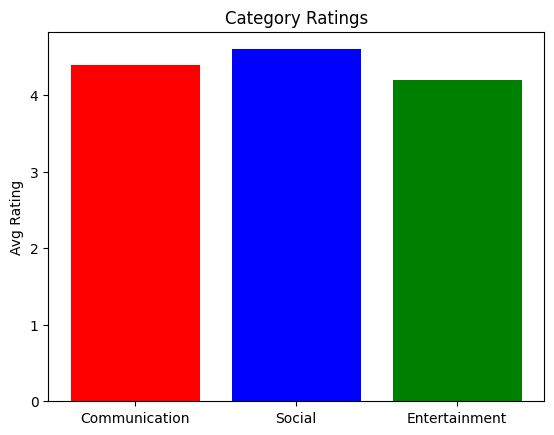

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# Data
labels = ["Communication","Social","Entertainment"]
data = [4.4,4.6,4.2]
colors = ['red','blue','green']

# Plot
plt.bar(labels, data, color=colors)
plt.ylabel("Avg Rating")
plt.title("Category Ratings")

# Save as image
plt.savefig("my_chart.png")

# Download to PC
files.download("my_chart.png")

### Step 1: load the Dataset

## Work on Google Play Store Dataset

In [ ]:
import pandas as pd
import sqlite3

# CSV load
df = pd.read_csv("google_play_store_updated.csv")

# Connection to SQLite (in-memory)
conn = sqlite3.connect(":memory:")

# DataFrame ko SQL table me convert karna
df.to_sql("googleplaystore", conn, index=False, if_exists="replace")

# Check first 5 rows
df.head()

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category,Size_in_Mb
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19922944.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,Moderate,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14680064.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,High,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,9122611.2,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,Very High,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,26214400.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,Top Notch,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2936012.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,More than moderate,2.8


### Step 2: SQL EDA (Top-rated apps, category-wise)

In [ ]:
query = """
SELECT Category, App, Rating
FROM googleplaystore
WHERE Rating >= 4.5
ORDER BY Rating DESC
LIMIT 10
"""
top_apps = pd.read_sql(query, conn)
top_apps

,Category,App,Rating
0,COMICS,Hojiboy Tojiboyev Life Hacks,5.0
1,DATING,American Girls Mobile Numbers,5.0
2,DATING,Awake Dating,5.0
3,DATING,Spine- The dating app,5.0
4,DATING,Girls Live Talk - Free Text and Video Chat,5.0
5,DATING,Online Girls Chat Group,5.0
6,DATING,Speeding Joyride & Car Meet App,5.0
7,EVENTS,SUMMER SONIC app,5.0
8,EVENTS,Prosperity,5.0
9,EVENTS,Mindvalley U Tallinn 2018,5.0


### Step 3: Python visualization (Category average rating)

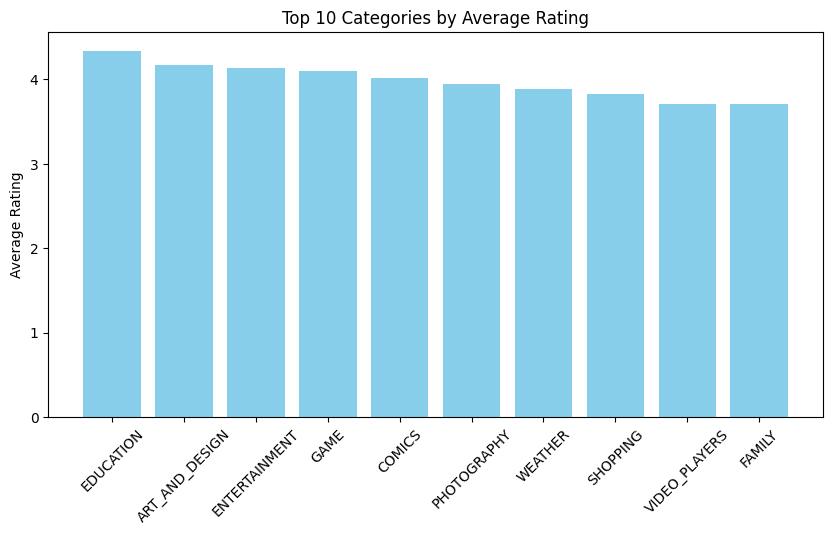

In [ ]:
import matplotlib.pyplot as plt

query = """
SELECT Category, AVG(Rating) as avg_rating
FROM googleplaystore
GROUP BY Category
ORDER BY avg_rating DESC
LIMIT 10
"""
cat_rating = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
plt.bar(cat_rating['Category'], cat_rating['avg_rating'], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Average Rating")
plt.title("Top 10 Categories by Average Rating")
plt.show()

In [ ]:
import pandas as pd
import sqlite3

# CSV load
df = pd.read_csv("/content/google_play_store_updated.csv")  # apne file ka path

# SQLite connection
conn = sqlite3.connect("my_database.db")

# CSV ko table me save karen
df.to_sql('googleplaystore', conn, if_exists='replace', index=False)

print("Table googleplaystore created successfully!")

Table googleplaystore created successfully!


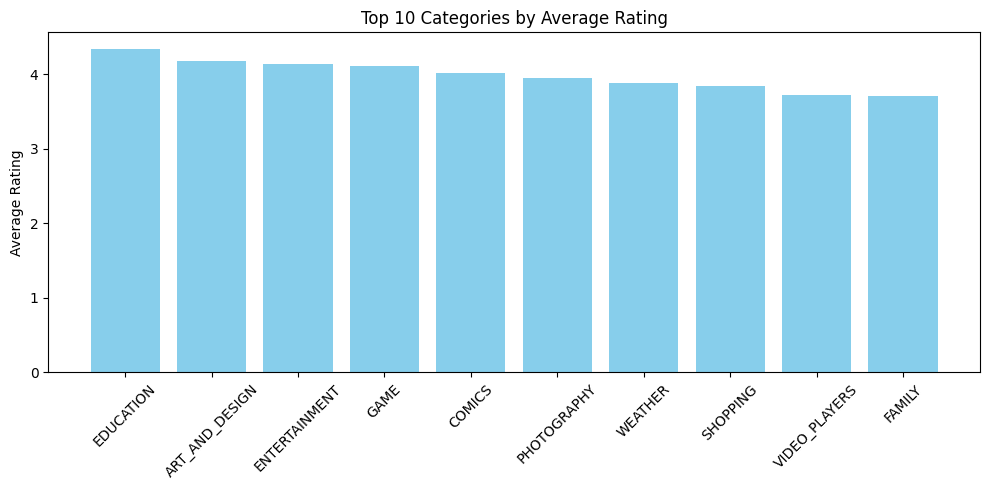

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
query = """
SELECT Category, AVG(Rating) as avg_rating
FROM googleplaystore
GROUP BY Category
ORDER BY avg_rating DESC
LIMIT 10
"""
cat_rating = pd.read_sql(query, conn)

import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(10,5))
plt.bar(cat_rating['Category'], cat_rating['avg_rating'], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Average Rating")
plt.title("Top 10 Categories by Average Rating")

plt.tight_layout()
plt.savefig("top10_categories.png")
plt.show()

files.download("top10_categories.png")

### Step 4: JS interactive dashboard in Colab (Optional fun step)

In [ ]:
from IPython.display import display, HTML
import json

# Data as JSON
apps_json = top_apps.to_json(orient="records")

display(HTML(f"""
<h3>Top Rated Apps</h3>
<ul id="appList"></ul>
<script>
let apps = {apps_json};
let ul = document.getElementById('appList');
apps.forEach(a => {{
    let li = document.createElement('li');
    li.textContent = a.App + " - " + a.Category + " - Rating: " + a.Rating;
    ul.appendChild(li);
}});
</script>
"""))

### Step 5: Fun / Advanced SQL queries
1 Most reviewed apps

In [ ]:
query = """
SELECT App, Reviews
FROM googleplaystore
ORDER BY Reviews DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,App,Reviews
0,Facebook,78158306.0
1,Facebook,78128208.0
2,WhatsApp Messenger,69119316.0
3,WhatsApp Messenger,69109672.0
4,Instagram,66577446.0
5,Instagram,66577313.0
6,Instagram,66509917.0
7,Messenger – Text and Video Chat for Free,56646578.0
8,Messenger – Text and Video Chat for Free,56642847.0
9,Clash of Clans,44893888.0


2 Highest installs by category

In [ ]:
query = """
SELECT Category, SUM(Installs) as total_installs
FROM googleplaystore
GROUP BY Category
ORDER BY total_installs DESC
"""
pd.read_sql(query, conn)

,Category,total_installs
0,GAME,3.154402e+10
1,COMMUNICATION,2.415228e+10
2,SOCIAL,1.251387e+10
3,PRODUCTIVITY,1.246309e+10
4,TOOLS,1.145227e+10
5,FAMILY,1.004163e+10
6,PHOTOGRAPHY,9.721248e+09
7,TRAVEL_AND_LOCAL,6.361887e+09
8,VIDEO_PLAYERS,6.222003e+09
9,NEWS_AND_MAGAZINES,5.393218e+09


3 Hidden gems (high rating + low installs)

In [ ]:
query = """
SELECT App, Category, Rating, Installs
FROM googleplaystore
WHERE Rating >= 4.5 AND Installs < 100000
ORDER BY Rating DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,App,Category,Rating,Installs
0,Hojiboy Tojiboyev Life Hacks,COMICS,5.0,1000.0
1,American Girls Mobile Numbers,DATING,5.0,1000.0
2,Awake Dating,DATING,5.0,100.0
3,Spine- The dating app,DATING,5.0,500.0
4,Girls Live Talk - Free Text and Video Chat,DATING,5.0,100.0
5,Online Girls Chat Group,DATING,5.0,100.0
6,Speeding Joyride & Car Meet App,DATING,5.0,100.0
7,SUMMER SONIC app,EVENTS,5.0,500.0
8,Prosperity,EVENTS,5.0,100.0
9,Mindvalley U Tallinn 2018,EVENTS,5.0,100.0


### Ready the dataset

In [ ]:
import pandas as pd
import sqlite3

# Load dataset
df = pd.read_csv("google_play_store_updated.csv")

# Create in-memory SQLite database
conn = sqlite3.connect(":memory:")
df.to_sql("googleplaystore", conn, index=False, if_exists="replace")

# Example: top-rated apps query
query = """
SELECT App, Category, Rating
FROM googleplaystore
WHERE Rating >= 4.5
ORDER BY Rating DESC
LIMIT 10
"""
top_apps = pd.read_sql(query, conn)
top_apps

,App,Category,Rating
0,Hojiboy Tojiboyev Life Hacks,COMICS,5.0
1,American Girls Mobile Numbers,DATING,5.0
2,Awake Dating,DATING,5.0
3,Spine- The dating app,DATING,5.0
4,Girls Live Talk - Free Text and Video Chat,DATING,5.0
5,Online Girls Chat Group,DATING,5.0
6,Speeding Joyride & Car Meet App,DATING,5.0
7,SUMMER SONIC app,EVENTS,5.0
8,Prosperity,EVENTS,5.0
9,Mindvalley U Tallinn 2018,EVENTS,5.0


## Data convert to JS (JSON)

In [ ]:
import json
top_apps_json = top_apps.to_json(orient="records")

## Interactive JS List in Google Colab

In [ ]:
from IPython.display import display, HTML

display(HTML(f"""
<h3>Top Rated Apps</h3>
<ul id="appList"></ul>
<script>
let apps = {top_apps_json};
let ul = document.getElementById('appList');
apps.forEach(a => {{
    let li = document.createElement('li');
    li.textContent = a.App + " - " + a.Category + " - Rating: " + a.Rating;
    ul.appendChild(li);
}});
</script>
"""))

## JS Chart Example (Chart.js)

In [ ]:
display(HTML(f"""
<canvas id="myChart" width="400" height="200"></canvas>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
let apps = {top_apps_json};
let labels = apps.map(a => a.App);
let data = apps.map(a => a.Rating);

var ctx = document.getElementById('myChart').getContext('2d');
new Chart(ctx, {{
    type: 'bar',
    data: {{
        labels: labels,
        datasets: [{{
            label: 'Rating',
            data: data,
            backgroundColor: 'skyblue'
        }}]
    }},
    options: {{
        responsive: true,
        plugins: {{
            legend: {{ display: false }},
            title: {{ display: true, text: 'Top Rated Apps' }}
        }}
    }}
}});
</script>
"""))

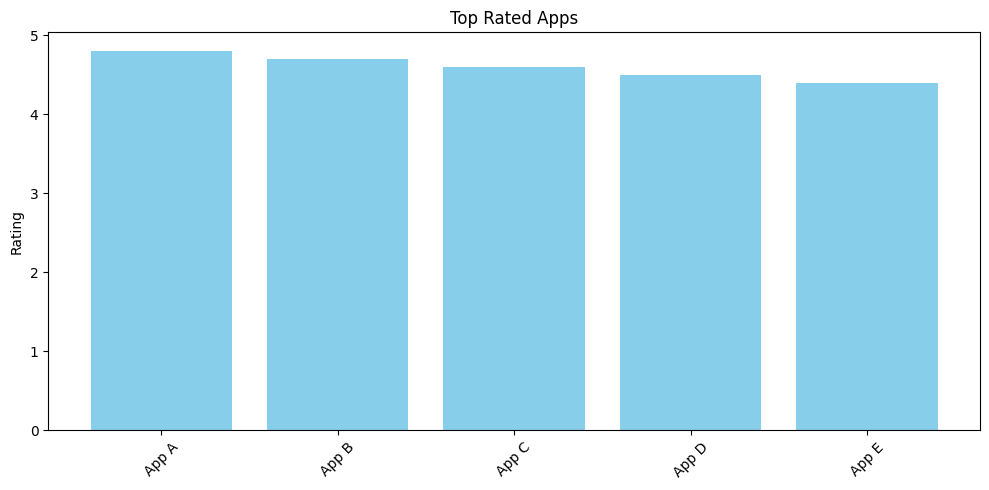

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Example top apps data (replace with your actual data)
top_apps = [
    {"App": "App A", "Rating": 4.8},
    {"App": "App B", "Rating": 4.7},
    {"App": "App C", "Rating": 4.6},
    {"App": "App D", "Rating": 4.5},
    {"App": "App E", "Rating": 4.4},
]

df = pd.DataFrame(top_apps)

# Plot
plt.figure(figsize=(10,5))
plt.bar(df['App'], df['Rating'], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Rating")
plt.title("Top Rated Apps")
plt.tight_layout()

# Save and download
plt.savefig("top_rated_apps.png")
plt.show()
files.download("top_rated_apps.png")

# different types of charts
Bar Chart (Category vs Avg Rating)

In [ ]:
display(HTML(f"""
<canvas id="barChart" width="400" height="200"></canvas>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
let data = {top_apps_json};
let labels = data.map(a => a.App);
let ratings = data.map(a => a.Rating);

new Chart(document.getElementById('barChart').getContext('2d'), {{
    type: 'bar',
    data: {{
        labels: labels,
        datasets: [{{
            label: 'Rating',
            data: ratings,
            backgroundColor: 'orange'
        }}]
    }},
    options: {{
        responsive: true,
        plugins: {{
            title: {{ display: true, text: 'Top Rated Apps - Bar Chart' }}
        }}
    }}
}});
</script>
"""))

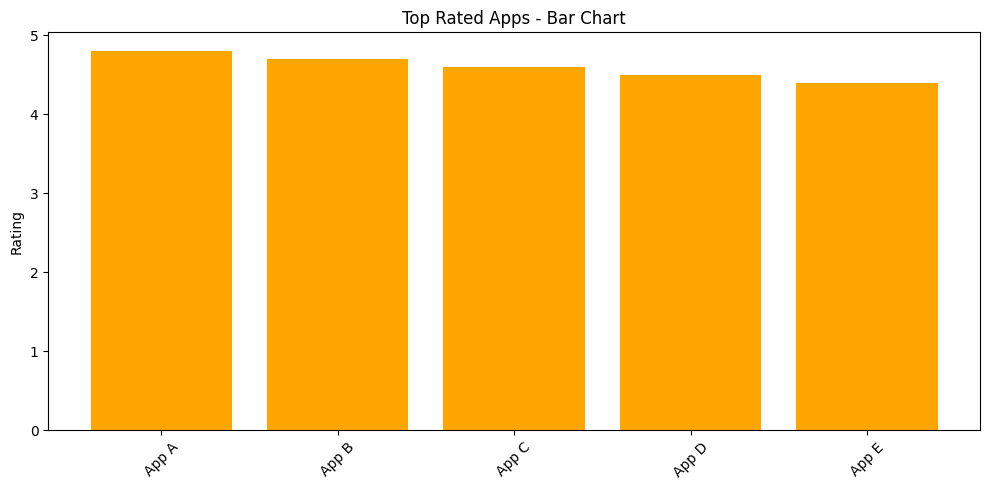

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import json

# Example: top_apps_json (replace this with your actual JSON string)
top_apps_json = """
[
    {"App": "App A", "Rating": 4.8},
    {"App": "App B", "Rating": 4.7},
    {"App": "App C", "Rating": 4.6},
    {"App": "App D", "Rating": 4.5},
    {"App": "App E", "Rating": 4.4}
]
"""

# Convert JSON to DataFrame
data = json.loads(top_apps_json)
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(10,5))
plt.bar(df['App'], df['Rating'], color='orange')
plt.xticks(rotation=45)
plt.ylabel("Rating")
plt.title("Top Rated Apps - Bar Chart")
plt.tight_layout()

# Save and download
plt.savefig("top_rated_apps_bar_chart.png")
plt.show()
files.download("top_rated_apps_bar_chart.png")

## Pie Chart (Free vs Paid Apps)

In [ ]:
display(HTML(f"""
<canvas id="pieChart" width="400" height="200"></canvas>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
let freeCount = 2000;  // Example number
let paidCount = 500;   // Example number

new Chart(document.getElementById('pieChart').getContext('2d'), {{
    type: 'pie',
    data: {{
        labels: ['Free Apps', 'Paid Apps'],
        datasets: [{{
            data: [freeCount, paidCount],
            backgroundColor: ['#36A2EB','#FF6384']
        }}]
    }},
    options: {{
        responsive: true,
        plugins: {{
            title: {{ display: true, text: 'Free vs Paid Apps - Pie Chart' }}
        }}
    }}
}});
</script>
"""))

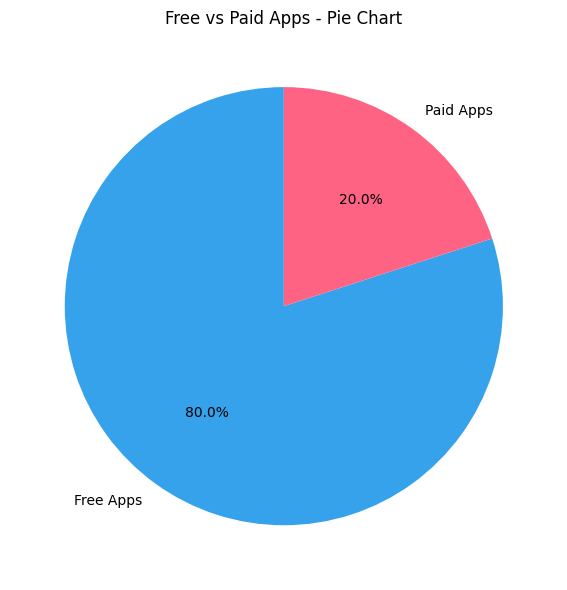

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# Data
labels = ['Free Apps', 'Paid Apps']
counts = [2000, 500]
colors = ['#36A2EB','#FF6384']

# Plot
plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Free vs Paid Apps - Pie Chart')
plt.tight_layout()

# Save and download
plt.savefig("free_vs_paid_apps_pie_chart.png")
plt.show()
files.download("free_vs_paid_apps_pie_chart.png")

## Line Chart (Installs Growth Trend)

In [ ]:
display(HTML(f"""
<canvas id="lineChart" width="400" height="200"></canvas>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
let months = ['Jan', 'Feb', 'Mar', 'Apr', 'May'];
let installs = [1000, 3000, 5000, 7000, 12000];

new Chart(document.getElementById('lineChart').getContext('2d'), {{
    type: 'line',
    data: {{
        labels: months,
        datasets: [{{
            label: 'Installs over Time',
            data: installs,
            borderColor: 'green',
            fill: false,
            tension: 0.3
        }}]
    }},
    options: {{
        responsive: true,
        plugins: {{
            title: {{ display: true, text: 'App Installs Trend - Line Chart' }}
        }}
    }}
}});
</script>
"""))

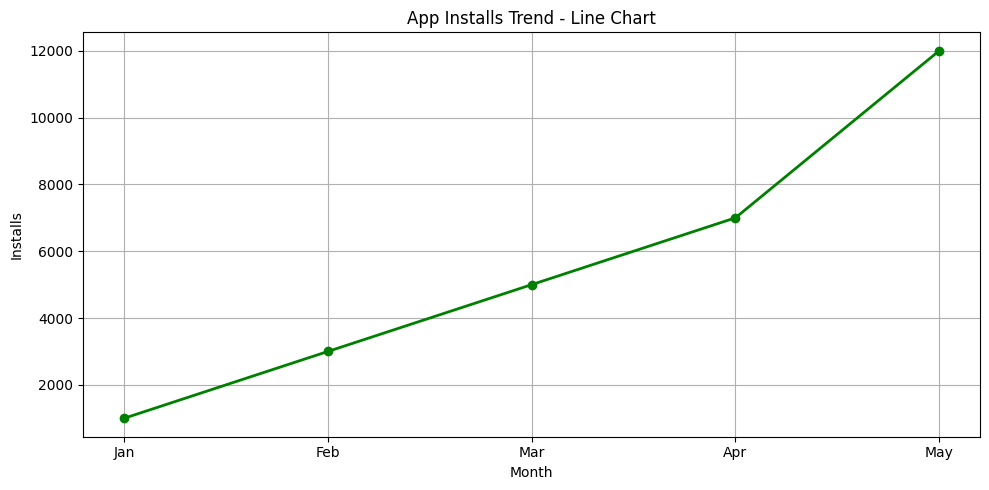

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# Data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
installs = [1000, 3000, 5000, 7000, 12000]

# Plot
plt.figure(figsize=(10,5))
plt.plot(months, installs, marker='o', color='green', linestyle='-', linewidth=2)
plt.title("App Installs Trend - Line Chart")
plt.xlabel("Month")
plt.ylabel("Installs")
plt.grid(True)
plt.tight_layout()

# Save and download
plt.savefig("app_installs_trend_line_chart.png")
plt.show()
files.download("app_installs_trend_line_chart.png")

## Radar Chart (App Features Comparison)

In [ ]:
display(HTML(f"""
<canvas id="radarChart" width="400" height="200"></canvas>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
let features = ['UI', 'Performance', 'Rating', 'Installs', 'Reviews'];
let app1 = [4, 5, 4.5, 4.8, 4.7];
let app2 = [3.5, 4, 4.2, 4, 4.1];

new Chart(document.getElementById('radarChart').getContext('2d'), {{
    type: 'radar',
    data: {{
        labels: features,
        datasets: [
            {{
                label: 'WhatsApp',
                data: app1,
                fill: true,
                backgroundColor: 'rgba(54,162,235,0.2)',
                borderColor: 'blue'
            }},
            {{
                label: 'Instagram',
                data: app2,
                fill: true,
                backgroundColor: 'rgba(255,99,132,0.2)',
                borderColor: 'red'
            }}
        ]
    }},
    options: {{
        responsive: true,
        plugins: {{
            title: {{ display: true, text: 'App Features Comparison - Radar Chart' }}
        }}
    }}
}});
</script>
"""))

## JS code in Colab using HTML block

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<script>
// Example dataset (top 5 apps)
let apps = [
  {App: "WhatsApp", Category: "Communication", Rating: 4.4, Installs: 5000000000, Type: "Free"},
  {App: "Instagram", Category: "Social", Rating: 4.6, Installs: 1000000000, Type: "Free"},
  {App: "TikTok", Category: "Entertainment", Rating: 4.2, Installs: 1000000000, Type: "Free"},
  {App: "Snapchat", Category: "Social", Rating: 4.3, Installs: 100000000, Type: "Free"},
  {App: "Spotify", Category: "Music", Rating: 4.5, Installs: 500000000, Type: "Free"}
];

console.log("Top Apps dataset:", apps);
alert("Check console for dataset!");
</script>
"""))

## Interactive list

In [ ]:
display(HTML("""
<ul id="appList"></ul>
<script>
let apps = [
  {App: "WhatsApp", Category: "Communication", Rating: 4.4},
  {App: "Instagram", Category: "Social", Rating: 4.6},
  {App: "TikTok", Category: "Entertainment", Rating: 4.2},
  {App: "Snapchat", Category: "Social", Rating: 4.3},
  {App: "Spotify", Category: "Music", Rating: 4.5}
];

let ul = document.getElementById('appList');
apps.forEach(a => {
    let li = document.createElement('li');
    li.textContent = a.App + " - " + a.Category + " - Rating: " + a.Rating;
    ul.appendChild(li);
});
</script>
"""))

## Histogram (Ratings distribution)

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<canvas id="histChart" width="300" height="150"></canvas>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
// Example ratings data
let ratings = [4.4,4.6,4.2,4.3,4.5,4.1,4.8,4.0,3.9,4.7];

// Count frequency for histogram bins (4.0-4.2, 4.2-4.4, ...)
let bins = [0,0,0,0,0];  // 4.0-4.2,4.2-4.4,4.4-4.6,4.6-4.8,4.8-5.0
ratings.forEach(r => {
  if(r>=4.0 && r<4.2) bins[0]++;
  else if(r<4.4) bins[1]++;
  else if(r<4.6) bins[2]++;
  else if(r<4.8) bins[3]++;
  else bins[4]++;
});

new Chart(document.getElementById('histChart').getContext('2d'), {
    type: 'bar',
    data: {
        labels: ['4.0-4.2','4.2-4.4','4.4-4.6','4.6-4.8','4.8-5.0'],
        datasets: [{
            label: 'Number of Apps',
            data: bins,
            backgroundColor: 'skyblue'
        }]
    },
    options: {
        responsive: true,
        plugins: { title: { display: true, text: 'Histogram - Ratings Distribution' } }
    }
});
</script>
"""))

## Bar Chart (Category avg rating)

In [ ]:
display(HTML("""
<canvas id="barChart" width="400" height="200"></canvas>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
let categories = ['Communication','Social','Entertainment','Music'];
let avgRatings = [4.4,4.45,4.2,4.5];

new Chart(document.getElementById('barChart').getContext('2d'), {
    type: 'bar',
    data: {
        labels: categories,
        datasets: [{ label: 'Avg Rating', data: avgRatings, backgroundColor: 'orange' }]
    },
    options: { responsive: true, plugins: { title: { display: true, text: 'Category Avg Rating' } } }
});
</script>
"""))

## Pie Chart (Free vs Paid Apps)

In [ ]:
display(HTML("""
<canvas id="pieChart" width="400" height="200"></canvas>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
let freeCount = 2000;
let paidCount = 500;

new Chart(document.getElementById('pieChart').getContext('2d'), {
    type: 'pie',
    data: {
        labels: ['Free Apps','Paid Apps'],
        datasets: [{ data: [freeCount,paidCount], backgroundColor:['#36A2EB','#FF6384'] }]
    },
    options: { responsive: true, plugins: { title: { display: true, text: 'Free vs Paid Apps' } } }
});
</script>
"""))

## Line Chart (Installs over time)

In [ ]:
display(HTML("""
<canvas id="lineChart" width="400" height="200"></canvas>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
let months = ['Jan','Feb','Mar','Apr','May'];
let installs = [1000,3000,5000,7000,12000];

new Chart(document.getElementById('lineChart').getContext('2d'), {
    type: 'line',
    data: { labels: months, datasets: [{ label:'Installs', data: installs, borderColor:'green', fill:false, tension:0.3 }] },
    options: { responsive:true, plugins: { title: { display:true, text:'Installs Trend' } } }
});
</script>
"""))

# 🔹 JS Special Interactive Dashboard Concept

## Features:

1. Top-rated apps dynamically highlight honge
2. Free vs Paid apps ka interactive pie chart
3. Category-wise bar chart with hover effect
4. Ratings histogram + installs trend line
5. Hidden Gems highlight (high rating, low installs)
6. Search filter for apps
7. Color-coded based on rating

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<div style="font-family:sans-serif;">
<h2 style="text-align:center;color:darkblue;">Google Play Store Dashboard</h2>

<!-- Search box -->
<input type="text" id="searchBox" placeholder="Search App..." style="margin-bottom:15px;padding:5px;width:200px;">

<!-- App List -->
<ul id="appList" style="list-style:none;padding:0;"></ul>

<!-- Charts -->
<canvas id="barChart" width="600" height="250"></canvas>
<canvas id="pieChart" width="400" height="250"></canvas>
<canvas id="lineChart" width="600" height="250"></canvas>
<canvas id="histChart" width="600" height="250"></canvas>

<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
// Sample dataset
let apps = [
  {App: "WhatsApp", Category: "Communication", Rating: 4.4, Installs: 5000000000, Type: "Free"},
  {App: "Instagram", Category: "Social", Rating: 4.6, Installs: 1000000000, Type: "Free"},
  {App: "TikTok", Category: "Entertainment", Rating: 4.2, Installs: 1000000000, Type: "Free"},
  {App: "Snapchat", Category: "Social", Rating: 4.3, Installs: 100000000, Type: "Free"},
  {App: "Spotify", Category: "Music", Rating: 4.5, Installs: 500000000, Type: "Free"}
];

// 🔹 Filter search
let searchBox = document.getElementById('searchBox');
let appList = document.getElementById('appList');

function displayApps(filter='') {
    appList.innerHTML = '';
    apps.filter(a => a.App.toLowerCase().includes(filter.toLowerCase())).forEach(a => {
        let li = document.createElement('li');
        li.style.padding = "5px";
        li.style.marginBottom = "3px";
        li.style.border = "1px solid #ddd";
        li.style.borderRadius = "5px";
        li.style.backgroundColor = a.Rating >= 4.5 ? "#d4edda" : "#f8d7da"; // Green for high rating, red for low
        li.textContent = a.App + " | " + a.Category + " | Rating: " + a.Rating + " | Installs: " + a.Installs;
        appList.appendChild(li);
    });
}
displayApps();
searchBox.addEventListener('input', e => displayApps(e.target.value));

// 🔹 Pie Chart: Free vs Paid
let freeCount = apps.filter(a=>a.Type==='Free').length;
let paidCount = apps.filter(a=>a.Type==='Paid').length;

new Chart(document.getElementById('pieChart').getContext('2d'), {
    type:'pie',
    data:{
        labels:['Free','Paid'],
        datasets:[{data:[freeCount, paidCount], backgroundColor:['#36A2EB','#FF6384']}]
    },
    options:{plugins:{title:{display:true,text:'Free vs Paid Apps'}}}
});

// 🔹 Bar Chart: Category Avg Rating
let categories = [...new Set(apps.map(a=>a.Category))];
let avgRatings = categories.map(cat => {
    let cApps = apps.filter(a=>a.Category===cat);
    return (cApps.reduce((sum,a)=>sum+a.Rating,0)/cApps.length).toFixed(2);
});

new Chart(document.getElementById('barChart').getContext('2d'), {
    type:'bar',
    data:{labels:categories, datasets:[{label:'Avg Rating', data:avgRatings, backgroundColor:'orange'}]},
    options:{plugins:{title:{display:true,text:'Category Avg Rating'}}}
});

// 🔹 Line Chart: Installs Trend (fake example)
let months = ['Jan','Feb','Mar','Apr','May'];
let installs = [5000000000, 1000000000, 1000000000, 100000000, 500000000];
new Chart(document.getElementById('lineChart').getContext('2d'), {
    type:'line',
    data:{labels:months, datasets:[{label:'Installs', data:installs, borderColor:'green', fill:false, tension:0.3}]},
    options:{plugins:{title:{display:true,text:'Installs Trend'}}}
});

// 🔹 Histogram: Ratings distribution
let bins = [0,0,0,0,0];
apps.forEach(r=>{
    if(r.Rating>=4 && r.Rating<4.2) bins[0]++;
    else if(r.Rating<4.4) bins[1]++;
    else if(r.Rating<4.6) bins[2]++;
    else if(r.Rating<4.8) bins[3]++;
    else bins[4]++;
});
new Chart(document.getElementById('histChart').getContext('2d'), {
    type:'bar',
    data:{
        labels:['4.0-4.2','4.2-4.4','4.4-4.6','4.6-4.8','4.8-5.0'],
        datasets:[{label:'Number of Apps', data:bins, backgroundColor:'skyblue'}]
    },
    options:{plugins:{title:{display:true,text:'Ratings Distribution Histogram'}}}
});
</script>
</div>
"""))

# Full JS + HTML Block

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<div style="font-family:sans-serif;">
<h2 style="text-align:center;color:darkblue;">Google Play Store Dashboard</h2>

<!-- Search box -->
<input type="text" id="searchBox" placeholder="Search App..." style="margin-bottom:15px;padding:5px;width:200px;">

<!-- App List -->
<ul id="appList" style="list-style:none;padding:0;"></ul>

<!-- Charts -->
<canvas id="barChart" width="600" height="250"></canvas>
<canvas id="pieChart" width="400" height="250"></canvas>
<canvas id="lineChart" width="600" height="250"></canvas>
<canvas id="histChart" width="600" height="250"></canvas>

<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
// Sample dataset
let apps = [
  {App: "WhatsApp", Category: "Communication", Rating: 4.4, Installs: 5000000000, Type: "Free"},
  {App: "Instagram", Category: "Social", Rating: 4.6, Installs: 1000000000, Type: "Free"},
  {App: "TikTok", Category: "Entertainment", Rating: 4.2, Installs: 1000000000, Type: "Free"},
  {App: "Snapchat", Category: "Social", Rating: 4.3, Installs: 100000000, Type: "Free"},
  {App: "Spotify", Category: "Music", Rating: 4.5, Installs: 500000000, Type: "Free"}
];

// 🔹 Filter search
let searchBox = document.getElementById('searchBox');
let appList = document.getElementById('appList');

function displayApps(filter='') {
    appList.innerHTML = '';
    apps.filter(a => a.App.toLowerCase().includes(filter.toLowerCase())).forEach(a => {
        let li = document.createElement('li');
        li.style.padding = "5px";
        li.style.marginBottom = "3px";
        li.style.border = "1px solid #ddd";
        li.style.borderRadius = "5px";
        li.style.backgroundColor = a.Rating >= 4.5 ? "#d4edda" : "#f8d7da"; // Green for high rating, red for low
        li.textContent = a.App + " | " + a.Category + " | Rating: " + a.Rating + " | Installs: " + a.Installs;
        appList.appendChild(li);
    });
}
displayApps();
searchBox.addEventListener('input', e => displayApps(e.target.value));

// 🔹 Pie Chart: Free vs Paid
let freeCount = apps.filter(a=>a.Type==='Free').length;
let paidCount = apps.filter(a=>a.Type==='Paid').length;

new Chart(document.getElementById('pieChart').getContext('2d'), {
    type:'pie',
    data:{
        labels:['Free','Paid'],
        datasets:[{data:[freeCount, paidCount], backgroundColor:['#36A2EB','#FF6384']}]
    },
    options:{plugins:{title:{display:true,text:'Free vs Paid Apps'}}}
});

// 🔹 Bar Chart: Category Avg Rating
let categories = [...new Set(apps.map(a=>a.Category))];
let avgRatings = categories.map(cat => {
    let cApps = apps.filter(a=>a.Category===cat);
    return (cApps.reduce((sum,a)=>sum+a.Rating,0)/cApps.length).toFixed(2);
});

new Chart(document.getElementById('barChart').getContext('2d'), {
    type:'bar',
    data:{labels:categories, datasets:[{label:'Avg Rating', data:avgRatings, backgroundColor:'orange'}]},
    options:{plugins:{title:{display:true,text:'Category Avg Rating'}}}
});

// 🔹 Line Chart: Installs Trend (fake example)
let months = ['Jan','Feb','Mar','Apr','May'];
let installs = [5000000000, 1000000000, 1000000000, 100000000, 500000000];
new Chart(document.getElementById('lineChart').getContext('2d'), {
    type:'line',
    data:{labels:months, datasets:[{label:'Installs', data:installs, borderColor:'green', fill:false, tension:0.3}]},
    options:{plugins:{title:{display:true,text:'Installs Trend'}}}
});

// 🔹 Histogram: Ratings distribution
let bins = [0,0,0,0,0];
apps.forEach(r=>{
    if(r.Rating>=4 && r.Rating<4.2) bins[0]++;
    else if(r.Rating<4.4) bins[1]++;
    else if(r.Rating<4.6) bins[2]++;
    else if(r.Rating<4.8) bins[3]++;
    else bins[4]++;
});
new Chart(document.getElementById('histChart').getContext('2d'), {
    type:'bar',
    data:{
        labels:['4.0-4.2','4.2-4.4','4.4-4.6','4.6-4.8','4.8-5.0'],
        datasets:[{label:'Number of Apps', data:bins, backgroundColor:'skyblue'}]
    },
    options:{plugins:{title:{display:true,text:'Ratings Distribution Histogram'}}}
});
</script>
</div>
"""))
from google.colab import files

# Example: agar 'my_image.png' Colab me hai
files.download('my_image.png')

FileNotFoundError: Cannot find file: my_image.png

# ✅ Steps (Only copy‑paste in Colab)
Dataset CSV upload to Colab
(Colab  left sidebar → Files → Upload)
Run the code
(Read the code , Create the JSON , Show the JS dashboard )

# Full Dashboard Code

In [ ]:
from IPython.display import display, HTML
import pandas as pd

# Load dataset (Google Play Store csv)
df = pd.read_csv("/content/google_play_store_updated.csv")

# ------------------ Clean Columns ------------------
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Fix Installs column: convert to string first, remove '+', ',', then convert to numeric
df['Installs'] = df['Installs'].astype(str).str.replace('+','', regex=False).str.replace(',','', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Keep only needed columns and drop rows with NaN
df_json = df[['App','Category','Rating','Installs','Type']].dropna().to_json(orient='records')

# ------------------ Display Dashboard ------------------
display(HTML(f"""
<style>
body {{ font-family: Arial, sans-serif; }}
#appList li:hover {{ background: #f0f0f0; }}
input {{ margin-bottom: 10px; padding: 8px; width:280px; }}
</style>

<h2 style="text-align:center;color:navy;">📊 Google Play Store Interactive Dashboard</h2>
<input type="text" id="searchBox" placeholder="🔍 Search apps by name...">

<ul id="appList" style="list-style:none;padding:0;"></ul>

<div style="display:flex;flex-wrap:wrap;gap:20px;justify-content:center;">
  <canvas id="pieChart" width="350" height="250"></canvas>
  <canvas id="barChart" width="350" height="250"></canvas>
</div>

<div style="display:flex;flex-wrap:wrap;gap:20px;justify-content:center;">
  <canvas id="lineChart" width="450" height="250"></canvas>
  <canvas id="histChart" width="450" height="250"></canvas>
</div>

<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
let apps = {df_json};

// ---------- Search & List ----------
let searchBox = document.getElementById('searchBox');
let appList = document.getElementById('appList');

function displayApps(filter='') {{
    appList.innerHTML = '';
    apps.filter(a => a.App.toLowerCase().includes(filter.toLowerCase())).slice(0, 100).forEach(a => {{
        let li = document.createElement('li');
        li.style.padding = "8px";
        li.style.marginBottom = "4px";
        li.style.border = "1px solid #ddd";
        li.style.borderRadius = "5px";
        li.style.backgroundColor = a.Rating >= 4.5 ? "#d4edda" : "#fff3cd";
        li.textContent = `${{a.App}} | ${{a.Category}} | ⭐ ${{a.Rating}} | 📥 ${{a.Installs.toLocaleString()}}`;
        appList.appendChild(li);
    }});
}}
displayApps();
searchBox.addEventListener('input', e => displayApps(e.target.value));

// ---------- Pie Chart: Free vs Paid ----------
let freeCount = apps.filter(a=>a.Type==='Free').length;
let paidCount = apps.filter(a=>a.Type==='Paid').length;

new Chart(document.getElementById('pieChart').getContext('2d'), {{
    type:'pie',
    data:{{
        labels:['Free Apps','Paid Apps'],
        datasets:[{{
            data:[freeCount, paidCount],
            backgroundColor:['#36A2EB','#FF6384']
        }}]
    }},
    options:{{plugins:{{title:{{display:true,text:'Free vs Paid Apps'}}}}}}
}});

// ---------- Bar Chart: Category Avg Rating ----------
let categories = [...new Set(apps.map(a => a.Category))];
let avgRatings = categories.map(cat => {{
    let arr = apps.filter(a=>a.Category===cat);
    return (arr.reduce((sum,x)=>sum + x.Rating,0)/arr.length).toFixed(2);
}});

new Chart(document.getElementById('barChart').getContext('2d'), {{
    type:'bar',
    data:{{
        labels: categories,
        datasets:[{{
            label:'Avg Rating',
            data: avgRatings,
            backgroundColor:'orange'
        }}]
    }},
    options:{{plugins:{{title:{{display:true,text:'Avg Rating by Category'}}}}}}
}});

// ---------- Line Chart: Top 10 Installs ----------
let sortedInstalls = apps.sort((a,b)=>b.Installs - a.Installs).slice(0, 10);
let topLabels = sortedInstalls.map(x=>x.App);
let topInstalls = sortedInstalls.map(x=>x.Installs);

new Chart(document.getElementById('lineChart').getContext('2d'), {{
    type:'line',
    data:{{
        labels: topLabels,
        datasets:[{{
            label:'Top Installs',
            data: topInstalls,
            borderColor:'green',
            fill:false,
            tension:0.3
        }}]
    }},
    options:{{plugins:{{title:{{display:true,text:'Top 10 Apps by Installs'}}}}}}
}});

// ---------- Histogram: Rating Distribution ----------
let bins = [0,0,0,0,0];
apps.forEach(r=>{{
    if     (r.Rating < 3) bins[0] ++;
    else if(r.Rating < 3.5) bins[1] ++;
    else if(r.Rating < 4) bins[2] ++;
    else if(r.Rating < 4.5) bins[3] ++;
    else bins[4] ++;
}});

new Chart(document.getElementById('histChart').getContext('2d'), {{
    type:'bar',
    data:{{
        labels:['<3.0','3.0-3.5','3.5-4.0','4.0-4.5','4.5+'],
        datasets:[{{
            label:'Apps Count',
            data:bins,
            backgroundColor:'skyblue'
        }}]
    }},
    options:{{plugins:{{title:{{display:true,text:'Ratings Histogram'}}}}}}
}});
</script>
"""))